<a href="https://colab.research.google.com/github/Ebrar6565/smart-city-satellite-analysis/blob/main/notebooks/04_model_evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Eğitilmiş U-Net Modelinin Değerlendirilmesi

Bu notebook içerisinde daha önce eğitilen ve Google Drive'a kaydedilen en iyi U-Net modeli kullanılacaktır.

Gerçekleştirilecek işlemler:

- Kaydedilmiş model checkpoint'inin yüklenmesi
- Validation görüntülerinde tahmin maskelerinin oluşturulması
- Uydu görüntüsü, gerçek maske ve tahmin maskesinin karşılaştırılması
- Pixel Accuracy hesaplanması
- Sınıf bazında IoU ve Dice skorlarının hesaplanması
- Tahmin maskelerinden kentsel analiz göstergelerinin üretilmesi

In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn

from torch.utils.data import (
    Dataset,
    DataLoader,
    ConcatDataset
)

print("PyTorch sürümü:", torch.__version__)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Kullanılacak cihaz:", device)

PyTorch sürümü: 2.11.0+cpu
Kullanılacak cihaz: cpu


In [2]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [3]:
checkpoint_path = Path(
    "/content/drive/MyDrive/"
    "smart-city-satellite-analysis/models/"
    "best_unet_model.pth"
)

if not checkpoint_path.exists():
    raise FileNotFoundError(
        f"Model dosyası bulunamadı: {checkpoint_path}"
    )

checkpoint_size_mb = (
    checkpoint_path.stat().st_size / (1024 ** 2)
)

print("✅ Model dosyası bulundu.")
print(f"Dosya boyutu: {checkpoint_size_mb:.2f} MB")
print("Konum:", checkpoint_path)

✅ Model dosyası bulundu.
Dosya boyutu: 88.96 MB
Konum: /content/drive/MyDrive/smart-city-satellite-analysis/models/best_unet_model.pth


In [4]:
checkpoint = torch.load(
    checkpoint_path,
    map_location=device
)

print("Checkpoint içerisindeki bilgiler:")
print(checkpoint.keys())

print(
    "\nKaydedilen epoch:",
    checkpoint.get("epoch", "Bulunamadı")
)

print(
    "Validation loss:",
    checkpoint.get("validation_loss", "Bulunamadı")
)

print(
    "Sınıf sayısı:",
    checkpoint.get("num_classes", "Bulunamadı")
)

print(
    "Görüntü boyutu:",
    checkpoint.get("target_size", "Bulunamadı")
)

Checkpoint içerisindeki bilgiler:
dict_keys(['epoch', 'model_state_dict', 'optimizer_state_dict', 'validation_loss', 'class_names', 'num_classes', 'ignore_index', 'target_size'])

Kaydedilen epoch: 7
Validation loss: 1.458069086074829
Sınıf sayısı: 7
Görüntü boyutu: (256, 256)


In [5]:
checkpoint = torch.load(
    checkpoint_path,
    map_location=device
)

print("Checkpoint içerisindeki bilgiler:")
print(checkpoint.keys())

print(
    "\nKaydedilen epoch:",
    checkpoint.get("epoch", "Bulunamadı")
)

print(
    "Validation loss:",
    checkpoint.get("validation_loss", "Bulunamadı")
)

print(
    "Sınıf sayısı:",
    checkpoint.get("num_classes", "Bulunamadı")
)

print(
    "Görüntü boyutu:",
    checkpoint.get("target_size", "Bulunamadı")
)

Checkpoint içerisindeki bilgiler:
dict_keys(['epoch', 'model_state_dict', 'optimizer_state_dict', 'validation_loss', 'class_names', 'num_classes', 'ignore_index', 'target_size'])

Kaydedilen epoch: 7
Validation loss: 1.458069086074829
Sınıf sayısı: 7
Görüntü boyutu: (256, 256)


In [6]:
NUM_CLASSES = checkpoint["num_classes"]
IGNORE_INDEX = checkpoint["ignore_index"]
TARGET_SIZE = tuple(checkpoint["target_size"])
MODEL_CLASS_NAMES = checkpoint["class_names"]

print("Sınıf sayısı:", NUM_CLASSES)
print("Ignore index:", IGNORE_INDEX)
print("Hedef görüntü boyutu:", TARGET_SIZE)
print("\nSınıflar:")

for class_id, class_name in MODEL_CLASS_NAMES.items():
    print(f"{class_id}: {class_name}")

Sınıf sayısı: 7
Ignore index: 255
Hedef görüntü boyutu: (256, 256)

Sınıflar:
0: Background
1: Building
2: Road
3: Water
4: Barren
5: Forest
6: Agriculture


In [7]:
class DoubleConv(nn.Module):
    """
    İki adet convolution, batch normalization ve ReLU bloğu.
    """

    def __init__(self, input_channels, output_channels):
        super().__init__()

        self.layers = nn.Sequential(
            nn.Conv2d(
                input_channels,
                output_channels,
                kernel_size=3,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d(output_channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(
                output_channels,
                output_channels,
                kernel_size=3,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d(output_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.layers(x)


class UNet(nn.Module):

    def __init__(self, input_channels=3, num_classes=7):
        super().__init__()

        # Encoder
        self.encoder1 = DoubleConv(input_channels, 32)
        self.pool1 = nn.MaxPool2d(2)

        self.encoder2 = DoubleConv(32, 64)
        self.pool2 = nn.MaxPool2d(2)

        self.encoder3 = DoubleConv(64, 128)
        self.pool3 = nn.MaxPool2d(2)

        self.encoder4 = DoubleConv(128, 256)
        self.pool4 = nn.MaxPool2d(2)

        # Bottleneck
        self.bottleneck = DoubleConv(256, 512)

        # Decoder
        self.upconv4 = nn.ConvTranspose2d(
            512, 256, kernel_size=2, stride=2
        )
        self.decoder4 = DoubleConv(512, 256)

        self.upconv3 = nn.ConvTranspose2d(
            256, 128, kernel_size=2, stride=2
        )
        self.decoder3 = DoubleConv(256, 128)

        self.upconv2 = nn.ConvTranspose2d(
            128, 64, kernel_size=2, stride=2
        )
        self.decoder2 = DoubleConv(128, 64)

        self.upconv1 = nn.ConvTranspose2d(
            64, 32, kernel_size=2, stride=2
        )
        self.decoder1 = DoubleConv(64, 32)

        # Her piksel için 7 sınıf skoru
        self.output_layer = nn.Conv2d(
            32,
            num_classes,
            kernel_size=1
        )

    def forward(self, x):

        encoder1_output = self.encoder1(x)

        encoder2_output = self.encoder2(
            self.pool1(encoder1_output)
        )

        encoder3_output = self.encoder3(
            self.pool2(encoder2_output)
        )

        encoder4_output = self.encoder4(
            self.pool3(encoder3_output)
        )

        bottleneck_output = self.bottleneck(
            self.pool4(encoder4_output)
        )

        decoder4_output = self.upconv4(
            bottleneck_output
        )

        decoder4_output = torch.cat(
            [decoder4_output, encoder4_output],
            dim=1
        )

        decoder4_output = self.decoder4(
            decoder4_output
        )

        decoder3_output = self.upconv3(
            decoder4_output
        )

        decoder3_output = torch.cat(
            [decoder3_output, encoder3_output],
            dim=1
        )

        decoder3_output = self.decoder3(
            decoder3_output
        )

        decoder2_output = self.upconv2(
            decoder3_output
        )

        decoder2_output = torch.cat(
            [decoder2_output, encoder2_output],
            dim=1
        )

        decoder2_output = self.decoder2(
            decoder2_output
        )

        decoder1_output = self.upconv1(
            decoder2_output
        )

        decoder1_output = torch.cat(
            [decoder1_output, encoder1_output],
            dim=1
        )

        decoder1_output = self.decoder1(
            decoder1_output
        )

        logits = self.output_layer(
            decoder1_output
        )

        return logits


print("U-Net mimarisi tanımlandı.")

U-Net mimarisi tanımlandı.


In [8]:
model = UNet(
    input_channels=3,
    num_classes=NUM_CLASSES
).to(device)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

# Değerlendirme moduna geçiriyoruz
model.eval()

print("✅ Eğitilmiş model ağırlıkları yüklendi.")
print("Modelin bulunduğu cihaz:", device)
print("Model değerlendirme modunda mı?:", not model.training)

✅ Eğitilmiş model ağırlıkları yüklendi.
Modelin bulunduğu cihaz: cpu
Model değerlendirme modunda mı?: True


In [9]:
test_input = torch.randn(
    1,
    3,
    TARGET_SIZE[0],
    TARGET_SIZE[1]
).to(device)

with torch.no_grad():
    test_output = model(test_input)

print("Test girdisinin boyutu:")
print(test_input.shape)

print("\nModel çıktısının boyutu:")
print(test_output.shape)

test_prediction = torch.argmax(
    test_output,
    dim=1
)

print("\nTahmin maskesinin boyutu:")
print(test_prediction.shape)

Test girdisinin boyutu:
torch.Size([1, 3, 256, 256])

Model çıktısının boyutu:
torch.Size([1, 7, 256, 256])

Tahmin maskesinin boyutu:
torch.Size([1, 256, 256])


In [10]:
def remap_loveda_mask(mask_array):
    """
    LoveDA:
        0   -> 255, yok sayılacak
        1-7 -> 0-6, model sınıfları
    """

    remapped_mask = np.full(
        mask_array.shape,
        IGNORE_INDEX,
        dtype=np.uint8
    )

    valid_pixels = mask_array > 0

    remapped_mask[valid_pixels] = (
        mask_array[valid_pixels] - 1
    )

    return remapped_mask


class LoveDAEvaluationDataset(Dataset):

    def __init__(
        self,
        image_directory,
        mask_directory,
        file_names,
        target_size=(256, 256)
    ):
        self.image_directory = Path(image_directory)
        self.mask_directory = Path(mask_directory)
        self.file_names = list(file_names)
        self.target_size = target_size

    def __len__(self):
        return len(self.file_names)

    def __getitem__(self, index):

        file_name = self.file_names[index]

        image_path = (
            self.image_directory / file_name
        )

        mask_path = (
            self.mask_directory / file_name
        )

        image = Image.open(
            image_path
        ).convert("RGB")

        mask = Image.open(mask_path)

        image = image.resize(
            self.target_size,
            resample=Image.Resampling.BILINEAR
        )

        mask = mask.resize(
            self.target_size,
            resample=Image.Resampling.NEAREST
        )

        image_array = np.array(
            image,
            dtype=np.float32
        )

        mask_array = np.array(
            mask,
            dtype=np.uint8
        )

        mask_array = remap_loveda_mask(
            mask_array
        )

        image_tensor = torch.from_numpy(
            image_array
        ).permute(2, 0, 1)

        image_tensor = image_tensor / 255.0

        mask_tensor = torch.from_numpy(
            mask_array.astype(np.int64)
        )

        return image_tensor, mask_tensor, file_name


print("Evaluation Dataset sınıfı oluşturuldu.")

Evaluation Dataset sınıfı oluşturuldu.


In [11]:
validation_root = Path(
    "/content/drive/MyDrive/"
    "smart-city-satellite-analysis/data_samples"
)

urban_image_dir = validation_root / "Urban" / "images"
urban_mask_dir = validation_root / "Urban" / "masks"

rural_image_dir = validation_root / "Rural" / "images"
rural_mask_dir = validation_root / "Rural" / "masks"


def find_matching_files(
    image_directory,
    mask_directory
):
    image_files = {
        file_path.name
        for file_path in image_directory.glob("*.png")
    }

    mask_files = {
        file_path.name
        for file_path in mask_directory.glob("*.png")
    }

    return sorted(
        image_files & mask_files
    )


urban_files = find_matching_files(
    urban_image_dir,
    urban_mask_dir
)

rural_files = find_matching_files(
    rural_image_dir,
    rural_mask_dir
)

print("Urban validation çifti:", len(urban_files))
print("Rural validation çifti:", len(rural_files))
print("Toplam validation çifti:", len(urban_files) + len(rural_files))

Urban validation çifti: 20
Rural validation çifti: 20
Toplam validation çifti: 40


In [12]:
urban_evaluation_dataset = LoveDAEvaluationDataset(
    image_directory=urban_image_dir,
    mask_directory=urban_mask_dir,
    file_names=urban_files,
    target_size=TARGET_SIZE
)

rural_evaluation_dataset = LoveDAEvaluationDataset(
    image_directory=rural_image_dir,
    mask_directory=rural_mask_dir,
    file_names=rural_files,
    target_size=TARGET_SIZE
)

evaluation_dataset = ConcatDataset([
    urban_evaluation_dataset,
    rural_evaluation_dataset
])

evaluation_dataloader = DataLoader(
    evaluation_dataset,
    batch_size=4,
    shuffle=False,
    num_workers=0
)

print("Evaluation örnek sayısı:", len(evaluation_dataset))
print("Evaluation batch sayısı:", len(evaluation_dataloader))

Evaluation örnek sayısı: 40
Evaluation batch sayısı: 10


In [13]:
batch_images, batch_masks, batch_file_names = next(
    iter(evaluation_dataloader)
)

batch_images_device = batch_images.to(device)

with torch.no_grad():
    batch_logits = model(
        batch_images_device
    )

    batch_predictions = torch.argmax(
        batch_logits,
        dim=1
    )

batch_predictions = batch_predictions.cpu()

print("Dosya isimleri:")
print(batch_file_names)

print("\nGörüntü boyutları:")
print(batch_images.shape)

print("\nGerçek maske boyutları:")
print(batch_masks.shape)

print("\nTahmin maske boyutları:")
print(batch_predictions.shape)

print("\nTahmin edilen sınıflar:")
print(torch.unique(batch_predictions))

Dosya isimleri:
('3539.png', '3541.png', '3544.png', '3546.png')

Görüntü boyutları:
torch.Size([4, 3, 256, 256])

Gerçek maske boyutları:
torch.Size([4, 256, 256])

Tahmin maske boyutları:
torch.Size([4, 256, 256])

Tahmin edilen sınıflar:
tensor([0, 1, 2, 3, 4, 5, 6])


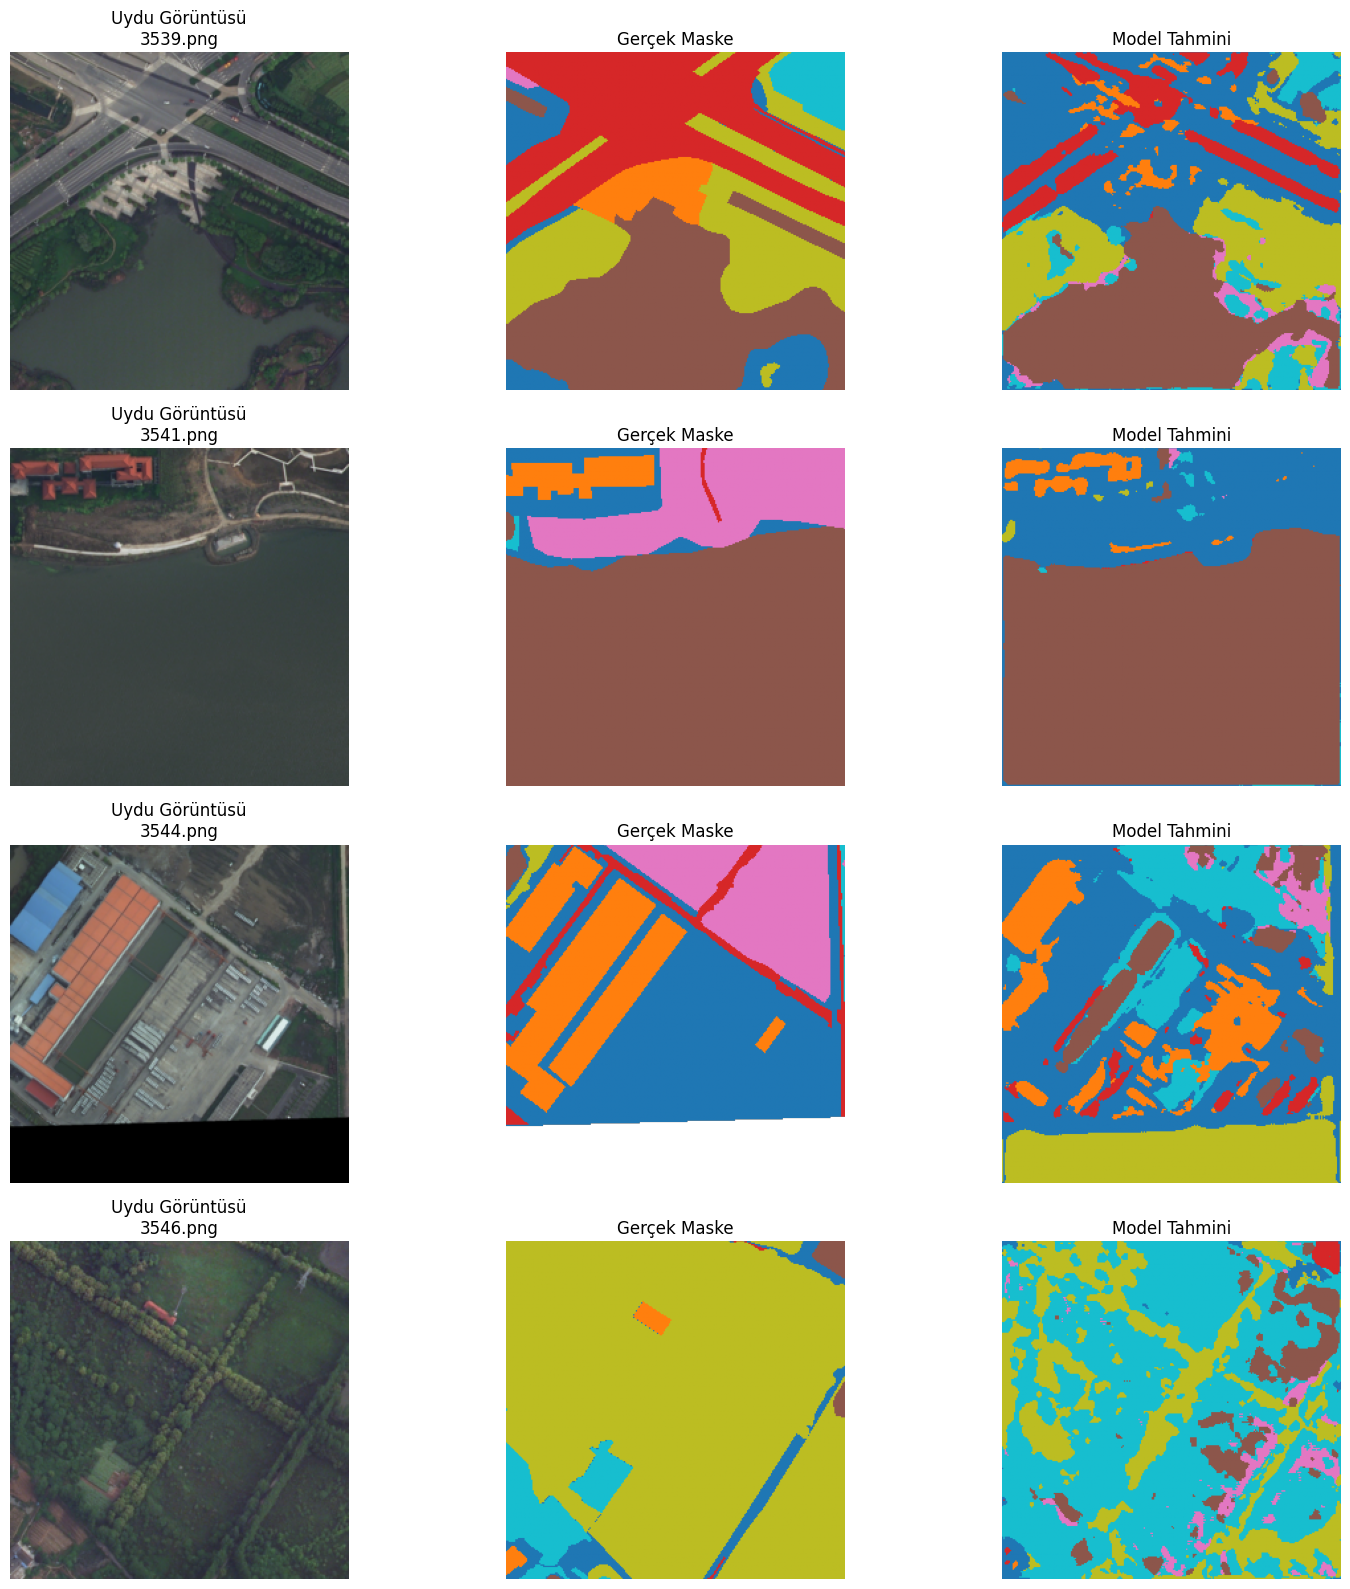

In [14]:
# İlk batch içerisinden kaç örnek göstereceğiz?
number_of_examples = 4

# 255 = no-data piksellerini görselleştirmede gizlemek için
IGNORE_INDEX = 255

# Ayrık sınıf renkleri
segmentation_cmap = plt.get_cmap(
    "tab10",
    NUM_CLASSES
)

plt.figure(figsize=(16, 4 * number_of_examples))

for index in range(number_of_examples):

    # PyTorch görüntüsü:
    # [C, H, W] -> [H, W, C]
    image = (
        batch_images[index]
        .permute(1, 2, 0)
        .numpy()
    )

    ground_truth_mask = (
        batch_masks[index]
        .numpy()
    )

    predicted_mask = (
        batch_predictions[index]
        .numpy()
    )

    # Gerçek maskedeki 255 piksellerini gizle
    visible_ground_truth = np.ma.masked_where(
        ground_truth_mask == IGNORE_INDEX,
        ground_truth_mask
    )

    # Uydu görüntüsü
    plt.subplot(
        number_of_examples,
        3,
        index * 3 + 1
    )

    plt.imshow(image)
    plt.title(
        f"Uydu Görüntüsü\n"
        f"{batch_file_names[index]}"
    )
    plt.axis("off")

    # Gerçek maske
    plt.subplot(
        number_of_examples,
        3,
        index * 3 + 2
    )

    plt.imshow(
        visible_ground_truth,
        cmap=segmentation_cmap,
        vmin=0,
        vmax=NUM_CLASSES - 1
    )

    plt.title("Gerçek Maske")
    plt.axis("off")

    # Model tahmini
    plt.subplot(
        number_of_examples,
        3,
        index * 3 + 3
    )

    plt.imshow(
        predicted_mask,
        cmap=segmentation_cmap,
        vmin=0,
        vmax=NUM_CLASSES - 1
    )

    plt.title("Model Tahmini")
    plt.axis("off")

plt.tight_layout()
plt.show()

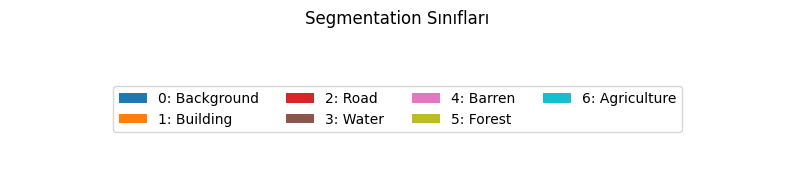

In [15]:
from matplotlib.patches import Patch

legend_elements = [
    Patch(
        facecolor=segmentation_cmap(class_id),
        label=f"{class_id}: {MODEL_CLASS_NAMES[class_id]}"
    )
    for class_id in range(NUM_CLASSES)
]

plt.figure(figsize=(10, 2))
plt.axis("off")

plt.legend(
    handles=legend_elements,
    loc="center",
    ncol=4,
    frameon=True
)

plt.title("Segmentation Sınıfları")
plt.show()

In [16]:
first_ground_truth = batch_masks[0]
first_prediction = batch_predictions[0]

# 255 olan pikseller değerlendirmeye katılmayacak
valid_pixels = (
    first_ground_truth != IGNORE_INDEX
)

correct_pixels = (
    first_prediction[valid_pixels]
    == first_ground_truth[valid_pixels]
).sum().item()

valid_pixel_count = valid_pixels.sum().item()

pixel_accuracy = (
    correct_pixels / valid_pixel_count
) * 100

print("Dosya:", batch_file_names[0])
print("Geçerli piksel sayısı:", valid_pixel_count)
print("Doğru tahmin edilen piksel:", correct_pixels)
print(f"Piksel doğruluğu: %{pixel_accuracy:.2f}")

Dosya: 3539.png
Geçerli piksel sayısı: 65536
Doğru tahmin edilen piksel: 36557
Piksel doğruluğu: %55.78


In [17]:
import torch
import numpy as np
import pandas as pd


def calculate_segmentation_metrics(
    model,
    dataloader,
    device,
    num_classes,
    ignore_index=255
):
    """
    Bütün validation verisi üzerinde confusion matrix oluşturur
    ve segmentation metriklerini hesaplar.
    """

    model.eval()

    confusion_matrix = torch.zeros(
        (num_classes, num_classes),
        dtype=torch.int64
    )

    with torch.no_grad():

        for images, ground_truth_masks, _ in dataloader:

            images = images.to(device)

            logits = model(images)

            predictions = torch.argmax(
                logits,
                dim=1
            ).cpu()

            # 255 olan no-data piksellerini çıkar
            valid_pixels = (
                ground_truth_masks != ignore_index
            )

            valid_ground_truth = ground_truth_masks[
                valid_pixels
            ].to(torch.int64)

            valid_predictions = predictions[
                valid_pixels
            ].to(torch.int64)

            # Her gerçek-tahmin sınıf çiftini tek indekse çevir
            combined_indices = (
                valid_ground_truth * num_classes
                + valid_predictions
            )

            batch_confusion_matrix = torch.bincount(
                combined_indices,
                minlength=num_classes ** 2
            ).reshape(
                num_classes,
                num_classes
            )

            confusion_matrix += batch_confusion_matrix

    # Her sınıf için doğru pozitifler
    true_positives = confusion_matrix.diag().float()

    # Gerçekte o sınıfa ait piksel sayısı
    ground_truth_counts = confusion_matrix.sum(
        dim=1
    ).float()

    # Modelin o sınıf olarak tahmin ettiği piksel sayısı
    prediction_counts = confusion_matrix.sum(
        dim=0
    ).float()

    # IoU paydası
    union = (
        ground_truth_counts
        + prediction_counts
        - true_positives
    )

    # Dice paydası
    dice_denominator = (
        ground_truth_counts
        + prediction_counts
    )

    iou_scores = torch.full(
        (num_classes,),
        float("nan")
    )

    dice_scores = torch.full(
        (num_classes,),
        float("nan")
    )

    valid_iou_classes = union > 0
    valid_dice_classes = dice_denominator > 0

    iou_scores[valid_iou_classes] = (
        true_positives[valid_iou_classes]
        / union[valid_iou_classes]
    )

    dice_scores[valid_dice_classes] = (
        2 * true_positives[valid_dice_classes]
        / dice_denominator[valid_dice_classes]
    )

    total_correct_pixels = true_positives.sum()
    total_valid_pixels = confusion_matrix.sum()

    pixel_accuracy = (
        total_correct_pixels / total_valid_pixels
    )

    mean_iou = torch.nanmean(iou_scores)
    mean_dice = torch.nanmean(dice_scores)

    return {
        "confusion_matrix": confusion_matrix,
        "iou_scores": iou_scores,
        "dice_scores": dice_scores,
        "pixel_accuracy": pixel_accuracy,
        "mean_iou": mean_iou,
        "mean_dice": mean_dice
    }


metrics = calculate_segmentation_metrics(
    model=model,
    dataloader=evaluation_dataloader,
    device=device,
    num_classes=NUM_CLASSES,
    ignore_index=IGNORE_INDEX
)

print("Metrikler başarıyla hesaplandı.")

Metrikler başarıyla hesaplandı.


In [19]:
print(
    f"Genel Pixel Accuracy: "
    f"%{metrics['pixel_accuracy'].item() * 100:.2f}"
)

print(
    f"Mean IoU: "
    f"%{metrics['mean_iou'].item() * 100:.2f}"
)

print(
    f"Mean Dice: "
    f"%{metrics['mean_dice'].item() * 100:.2f}"
)

Genel Pixel Accuracy: %44.35
Mean IoU: %21.19
Mean Dice: %33.62


In [20]:
class_results = []

for class_id in range(NUM_CLASSES):

    class_name = MODEL_CLASS_NAMES[class_id]

    iou_value = metrics["iou_scores"][
        class_id
    ].item()

    dice_value = metrics["dice_scores"][
        class_id
    ].item()

    class_results.append({
        "Sınıf ID": class_id,
        "Sınıf": class_name,
        "IoU (%)": (
            iou_value * 100
            if not np.isnan(iou_value)
            else np.nan
        ),
        "Dice (%)": (
            dice_value * 100
            if not np.isnan(dice_value)
            else np.nan
        )
    })


metrics_table = pd.DataFrame(
    class_results
)

metrics_table = metrics_table.round(2)

metrics_table

,Sınıf ID,Sınıf,IoU (%),Dice (%)
0,0,Background,39.97,57.11
1,1,Building,17.82,30.25
2,2,Road,14.01,24.58
3,3,Water,25.34,40.43
4,4,Barren,2.45,4.79
5,5,Forest,21.53,35.44
6,6,Agriculture,27.18,42.74


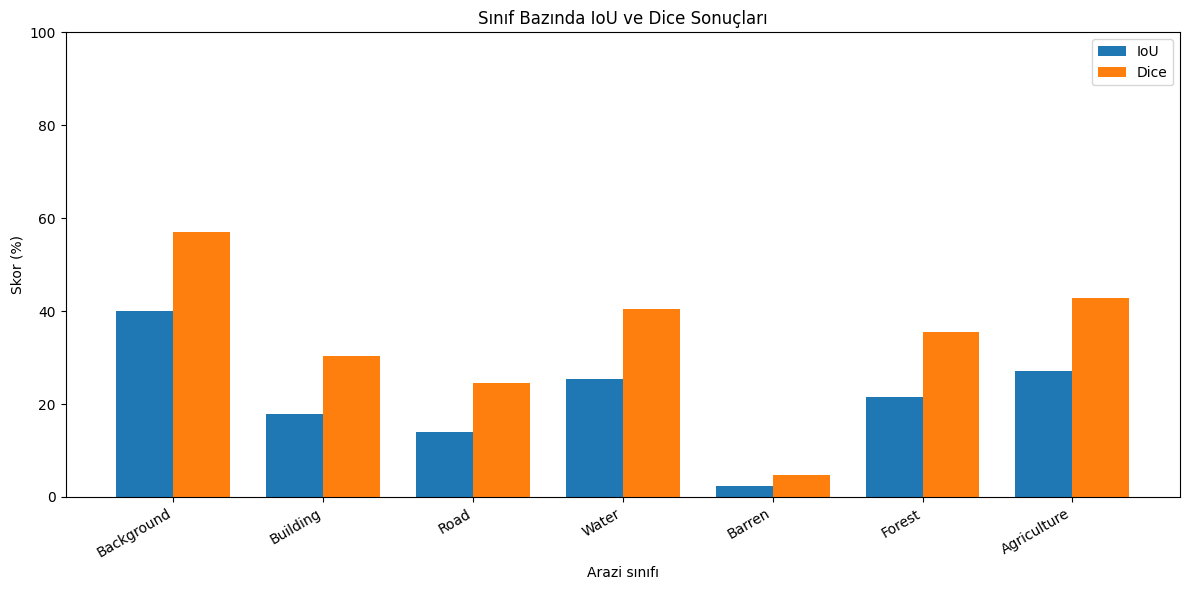

In [21]:
class_names = metrics_table["Sınıf"].tolist()
iou_values = metrics_table["IoU (%)"].tolist()
dice_values = metrics_table["Dice (%)"].tolist()

x_positions = np.arange(
    len(class_names)
)

bar_width = 0.38

plt.figure(figsize=(12, 6))

plt.bar(
    x_positions - bar_width / 2,
    iou_values,
    width=bar_width,
    label="IoU"
)

plt.bar(
    x_positions + bar_width / 2,
    dice_values,
    width=bar_width,
    label="Dice"
)

plt.title("Sınıf Bazında IoU ve Dice Sonuçları")
plt.xlabel("Arazi sınıfı")
plt.ylabel("Skor (%)")

plt.xticks(
    x_positions,
    class_names,
    rotation=30,
    ha="right"
)

plt.ylim(0, 100)
plt.legend()
plt.tight_layout()
plt.show()

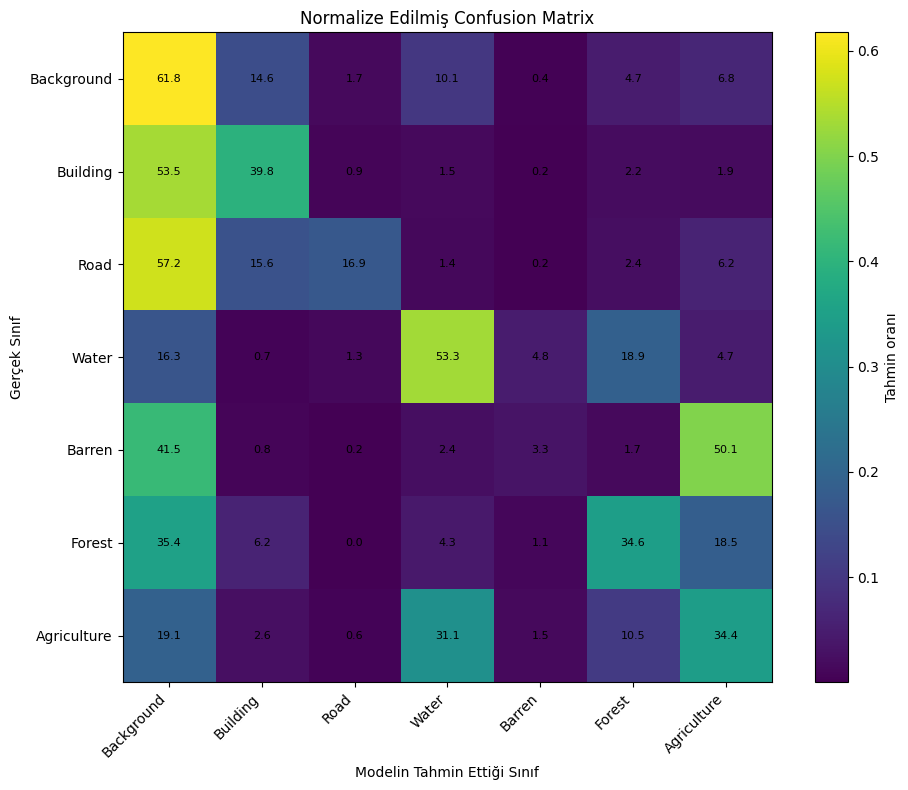

In [22]:
# Confusion matrix'i NumPy dizisine dönüştürüyoruz
confusion_matrix = (
    metrics["confusion_matrix"]
    .cpu()
    .numpy()
    .astype(np.float64)
)

# Her gerçek sınıf satırını kendi toplamına bölerek normalize ediyoruz
row_totals = confusion_matrix.sum(
    axis=1,
    keepdims=True
)

normalized_confusion_matrix = np.divide(
    confusion_matrix,
    row_totals,
    out=np.zeros_like(confusion_matrix),
    where=row_totals != 0
)

class_names = [
    MODEL_CLASS_NAMES[class_id]
    for class_id in range(NUM_CLASSES)
]

plt.figure(figsize=(10, 8))

matrix_plot = plt.imshow(
    normalized_confusion_matrix
)

plt.title("Normalize Edilmiş Confusion Matrix")
plt.xlabel("Modelin Tahmin Ettiği Sınıf")
plt.ylabel("Gerçek Sınıf")

plt.xticks(
    range(NUM_CLASSES),
    class_names,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(NUM_CLASSES),
    class_names
)

plt.colorbar(
    matrix_plot,
    label="Tahmin oranı"
)

for real_class in range(NUM_CLASSES):
    for predicted_class in range(NUM_CLASSES):

        value = normalized_confusion_matrix[
            real_class,
            predicted_class
        ]

        plt.text(
            predicted_class,
            real_class,
            f"{value * 100:.1f}",
            ha="center",
            va="center",
            fontsize=8
        )

plt.tight_layout()
plt.show()

In [23]:
import pandas as pd
import numpy as np


# İlk validation örneğini kullanıyoruz
selected_image = batch_images[0]
selected_ground_truth = batch_masks[0]
selected_prediction = batch_predictions[0]

selected_file_name = batch_file_names[0]

# No-data olmayan pikseller
valid_pixels = (
    selected_ground_truth != IGNORE_INDEX
)

ground_truth_valid = selected_ground_truth[
    valid_pixels
]

prediction_valid = selected_prediction[
    valid_pixels
]

valid_pixel_count = valid_pixels.sum().item()

comparison_results = []

for class_id in range(NUM_CLASSES):

    class_name = MODEL_CLASS_NAMES[class_id]

    ground_truth_pixel_count = (
        ground_truth_valid == class_id
    ).sum().item()

    predicted_pixel_count = (
        prediction_valid == class_id
    ).sum().item()

    ground_truth_percentage = (
        ground_truth_pixel_count
        / valid_pixel_count
        * 100
    )

    predicted_percentage = (
        predicted_pixel_count
        / valid_pixel_count
        * 100
    )

    comparison_results.append({
        "Sınıf": class_name,
        "Gerçek Oran (%)": ground_truth_percentage,
        "Tahmin Oranı (%)": predicted_percentage,
        "Fark (%)": (
            predicted_percentage
            - ground_truth_percentage
        )
    })


area_comparison_table = pd.DataFrame(
    comparison_results
).round(2)

print("Dosya:", selected_file_name)

area_comparison_table

Dosya: 3539.png


,Sınıf,Gerçek Oran (%),Tahmin Oranı (%),Fark (%)
0,Background,7.70,31.33,23.64
1,Building,4.88,2.65,-2.22
2,Road,28.09,9.92,-18.18
3,Water,32.29,27.45,-4.84
4,Barren,0.28,2.82,2.54
5,Forest,23.08,19.15,-3.92
6,Agriculture,3.69,6.68,2.98


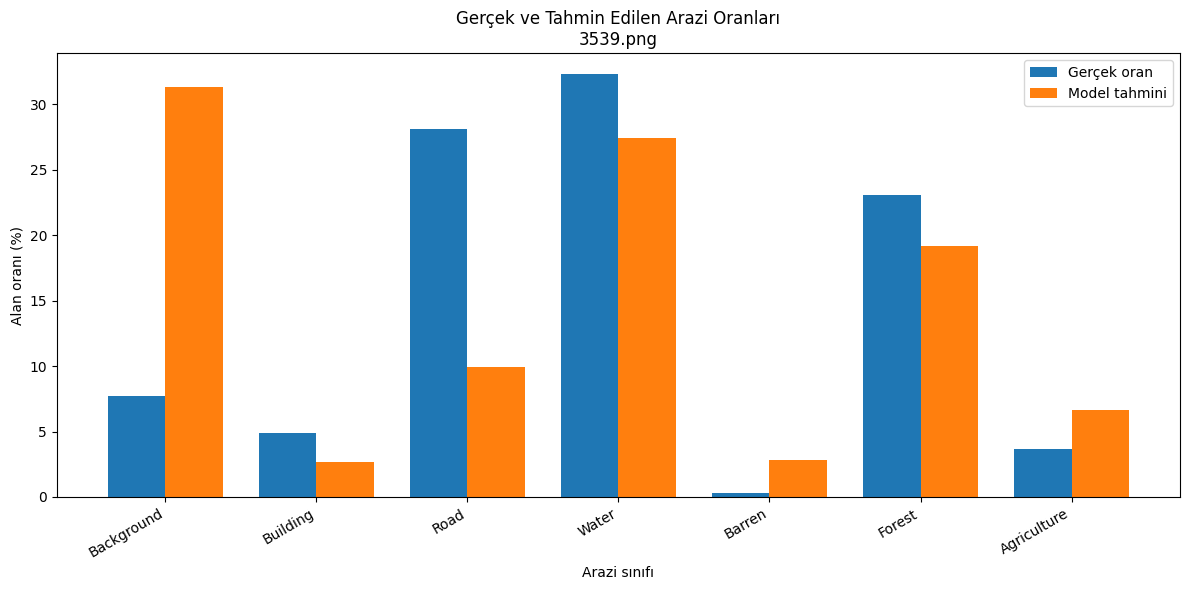

In [24]:
class_names = area_comparison_table[
    "Sınıf"
].tolist()

ground_truth_percentages = area_comparison_table[
    "Gerçek Oran (%)"
].tolist()

predicted_percentages = area_comparison_table[
    "Tahmin Oranı (%)"
].tolist()

x_positions = np.arange(
    len(class_names)
)

bar_width = 0.38

plt.figure(figsize=(12, 6))

plt.bar(
    x_positions - bar_width / 2,
    ground_truth_percentages,
    width=bar_width,
    label="Gerçek oran"
)

plt.bar(
    x_positions + bar_width / 2,
    predicted_percentages,
    width=bar_width,
    label="Model tahmini"
)

plt.title(
    f"Gerçek ve Tahmin Edilen Arazi Oranları\n"
    f"{selected_file_name}"
)

plt.xlabel("Arazi sınıfı")
plt.ylabel("Alan oranı (%)")

plt.xticks(
    x_positions,
    class_names,
    rotation=30,
    ha="right"
)

plt.legend()
plt.tight_layout()
plt.show()

In [25]:
BUILDING_CLASS_ID = 1
GRID_ROWS = 8
GRID_COLUMNS = 8


def calculate_building_density_maps(
    ground_truth_mask,
    predicted_mask,
    grid_rows=8,
    grid_columns=8,
    building_class_id=1,
    ignore_index=255
):
    """
    Gerçek ve tahmin edilen maskeler için bölgesel
    bina yoğunluğu haritalarını hesaplar.

    Her iki haritada da aynı geçerli piksel alanları kullanılır.
    """

    ground_truth_array = np.asarray(ground_truth_mask)
    predicted_array = np.asarray(predicted_mask)

    height, width = ground_truth_array.shape

    row_boundaries = np.linspace(
        0,
        height,
        grid_rows + 1,
        dtype=int
    )

    column_boundaries = np.linspace(
        0,
        width,
        grid_columns + 1,
        dtype=int
    )

    ground_truth_density = np.zeros(
        (grid_rows, grid_columns),
        dtype=np.float32
    )

    predicted_density = np.zeros(
        (grid_rows, grid_columns),
        dtype=np.float32
    )

    for row_index in range(grid_rows):
        for column_index in range(grid_columns):

            row_start = row_boundaries[row_index]
            row_end = row_boundaries[row_index + 1]

            column_start = column_boundaries[column_index]
            column_end = column_boundaries[column_index + 1]

            ground_truth_cell = ground_truth_array[
                row_start:row_end,
                column_start:column_end
            ]

            predicted_cell = predicted_array[
                row_start:row_end,
                column_start:column_end
            ]

            # Gerçek maskedeki no-data alanlarını çıkarıyoruz.
            valid_pixels = (
                ground_truth_cell != ignore_index
            )

            valid_pixel_count = valid_pixels.sum()

            if valid_pixel_count == 0:
                continue

            real_building_pixels = np.sum(
                (ground_truth_cell == building_class_id)
                & valid_pixels
            )

            predicted_building_pixels = np.sum(
                (predicted_cell == building_class_id)
                & valid_pixels
            )

            ground_truth_density[
                row_index,
                column_index
            ] = (
                real_building_pixels
                / valid_pixel_count
                * 100
            )

            predicted_density[
                row_index,
                column_index
            ] = (
                predicted_building_pixels
                / valid_pixel_count
                * 100
            )

    difference_density = (
        predicted_density
        - ground_truth_density
    )

    return {
        "ground_truth": ground_truth_density,
        "prediction": predicted_density,
        "difference": difference_density,
        "row_boundaries": row_boundaries,
        "column_boundaries": column_boundaries
    }


building_density_results = calculate_building_density_maps(
    ground_truth_mask=selected_ground_truth.numpy(),
    predicted_mask=selected_prediction.numpy(),
    grid_rows=GRID_ROWS,
    grid_columns=GRID_COLUMNS,
    building_class_id=BUILDING_CLASS_ID,
    ignore_index=IGNORE_INDEX
)

real_building_density = building_density_results[
    "ground_truth"
]

predicted_building_density = building_density_results[
    "prediction"
]

building_density_difference = building_density_results[
    "difference"
]

print("Gerçek bina yoğunluğu haritası:")
print(np.round(real_building_density, 1))

print("\nTahmin edilen bina yoğunluğu haritası:")
print(np.round(predicted_building_density, 1))

print("\nTahmin - gerçek farkı:")
print(np.round(building_density_difference, 1))

Gerçek bina yoğunluğu haritası:
[[ 0.   0.   0.   0.   0.   0.   0.   0. ]
 [ 0.   0.   0.   0.   0.   0.   0.   0. ]
 [ 0.   0.   7.8 38.8 39.2  0.   0.   0. ]
 [ 0.  10.3 86.2 62.7 63.6  0.   0.   0. ]
 [ 0.   0.   0.6  0.   2.9  0.   0.   0. ]
 [ 0.   0.   0.   0.   0.   0.   0.   0. ]
 [ 0.   0.   0.   0.   0.   0.   0.   0. ]
 [ 0.   0.   0.   0.   0.   0.   0.   0. ]]

Tahmin edilen bina yoğunluğu haritası:
[[ 0.   2.4 11.3  9.4 12.7  2.5  0.   0. ]
 [ 0.   6.2 31.6 16.2  6.4 12.6  0.3  0. ]
 [ 0.   0.   4.  18.5  8.6  0.   0.   0. ]
 [ 0.   0.   7.2 17.5  2.2  0.   0.   0. ]
 [ 0.   0.   0.   0.   0.   0.   0.   0. ]
 [ 0.   0.   0.   0.   0.   0.   0.   0. ]
 [ 0.   0.   0.   0.   0.   0.   0.   0. ]
 [ 0.   0.   0.   0.   0.   0.   0.   0. ]]

Tahmin - gerçek farkı:
[[  0.    2.4  11.3   9.4  12.7   2.5   0.    0. ]
 [  0.    6.2  31.6  16.2   6.4  12.6   0.3   0. ]
 [  0.    0.   -3.8 -20.3 -30.6   0.    0.    0. ]
 [  0.  -10.3 -79.  -45.2 -61.3   0.    0.    0. ]
 [  0.    

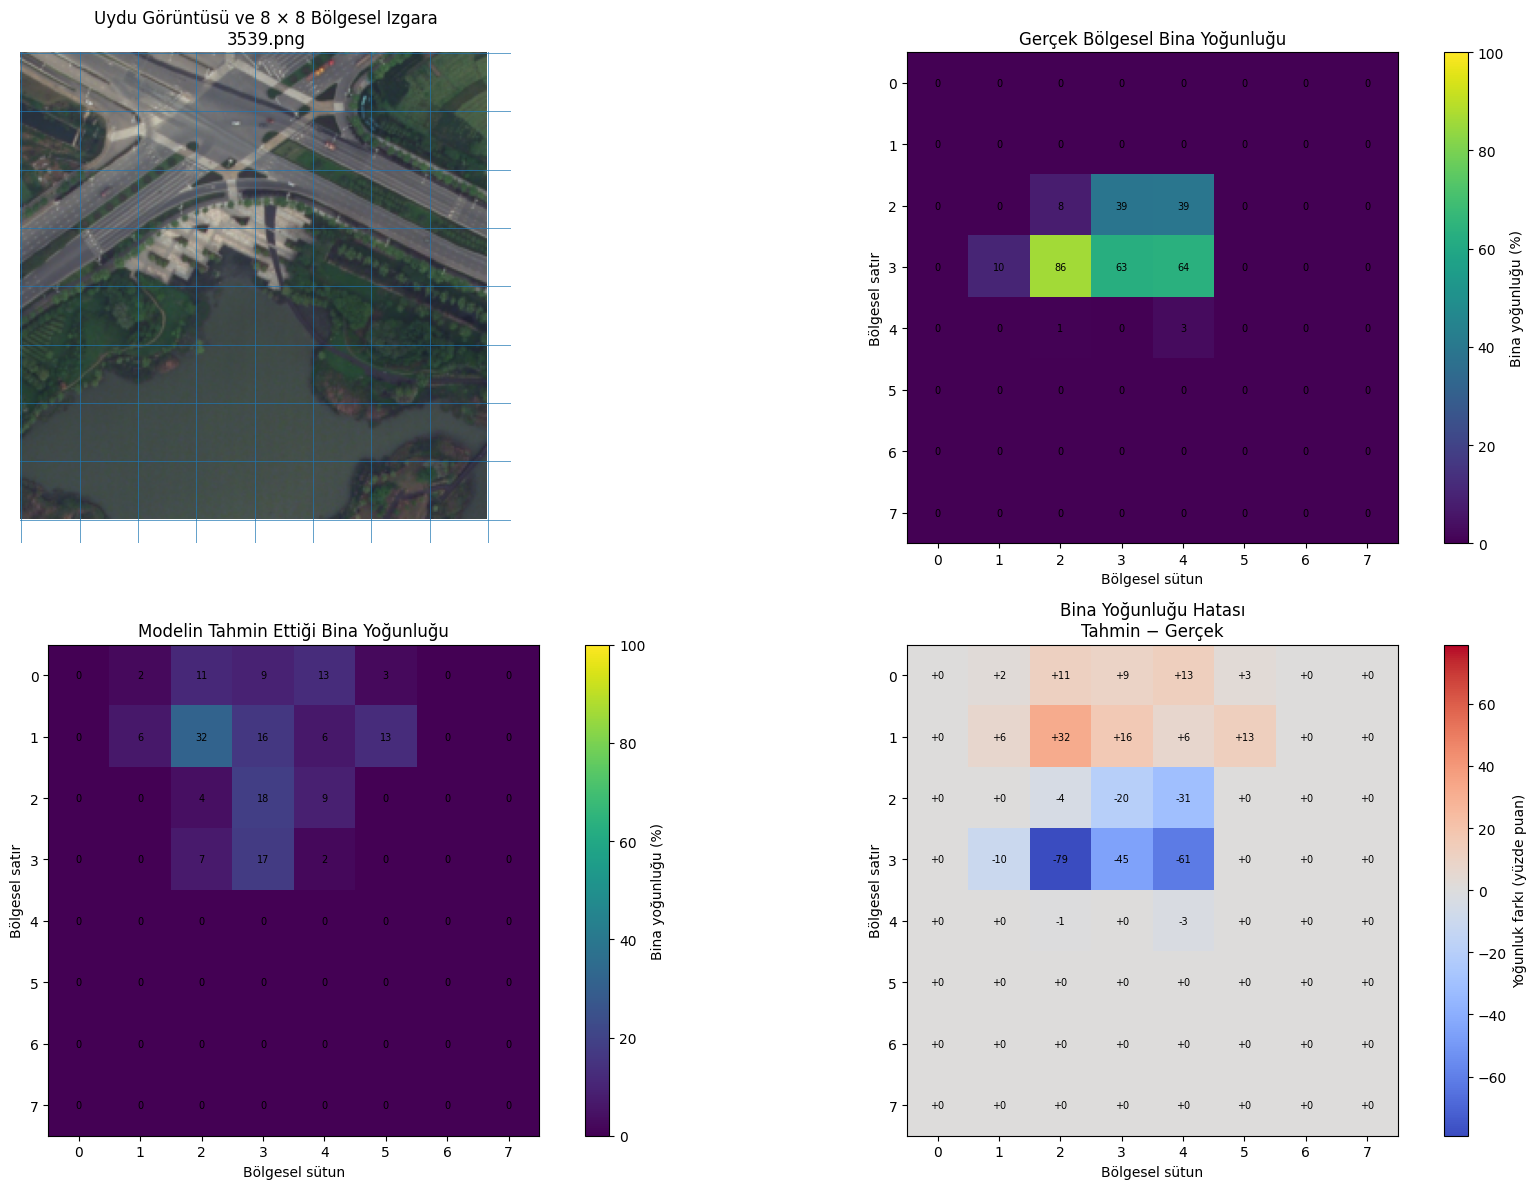

In [26]:
def write_density_values(
    density_map,
    text_format="{:.0f}",
    text_size=7
):
    """
    Isı haritasındaki hücrelerin üzerine değerleri yazar.
    """

    for row_index in range(density_map.shape[0]):
        for column_index in range(density_map.shape[1]):

            value = density_map[
                row_index,
                column_index
            ]

            plt.text(
                column_index,
                row_index,
                text_format.format(value),
                ha="center",
                va="center",
                fontsize=text_size
            )


image_for_display = (
    selected_image
    .permute(1, 2, 0)
    .numpy()
)

row_boundaries = building_density_results[
    "row_boundaries"
]

column_boundaries = building_density_results[
    "column_boundaries"
]


plt.figure(figsize=(18, 12))

# 1. Uydu görüntüsü ve bölgesel hücreler
plt.subplot(2, 2, 1)

plt.imshow(image_for_display)
plt.title(
    f"Uydu Görüntüsü ve 8 × 8 Bölgesel Izgara\n"
    f"{selected_file_name}"
)
plt.axis("off")

for row_boundary in row_boundaries:
    plt.axhline(
        row_boundary,
        linewidth=0.7,
        alpha=0.7
    )

for column_boundary in column_boundaries:
    plt.axvline(
        column_boundary,
        linewidth=0.7,
        alpha=0.7
    )


# 2. Gerçek bina yoğunluğu
plt.subplot(2, 2, 2)

real_density_plot = plt.imshow(
    real_building_density,
    vmin=0,
    vmax=100
)

plt.title("Gerçek Bölgesel Bina Yoğunluğu")
plt.xlabel("Bölgesel sütun")
plt.ylabel("Bölgesel satır")

plt.colorbar(
    real_density_plot,
    label="Bina yoğunluğu (%)"
)

write_density_values(
    real_building_density
)


# 3. Tahmin edilen bina yoğunluğu
plt.subplot(2, 2, 3)

predicted_density_plot = plt.imshow(
    predicted_building_density,
    vmin=0,
    vmax=100
)

plt.title("Modelin Tahmin Ettiği Bina Yoğunluğu")
plt.xlabel("Bölgesel sütun")
plt.ylabel("Bölgesel satır")

plt.colorbar(
    predicted_density_plot,
    label="Bina yoğunluğu (%)"
)

write_density_values(
    predicted_building_density
)


# 4. Tahmin ile gerçek arasındaki fark
plt.subplot(2, 2, 4)

maximum_absolute_difference = max(
    abs(building_density_difference.min()),
    abs(building_density_difference.max()),
    1
)

difference_plot = plt.imshow(
    building_density_difference,
    vmin=-maximum_absolute_difference,
    vmax=maximum_absolute_difference,
    cmap="coolwarm"
)

plt.title("Bina Yoğunluğu Hatası\nTahmin − Gerçek")
plt.xlabel("Bölgesel sütun")
plt.ylabel("Bölgesel satır")

plt.colorbar(
    difference_plot,
    label="Yoğunluk farkı (yüzde puan)"
)

write_density_values(
    building_density_difference,
    text_format="{:+.0f}"
)

plt.tight_layout()
plt.show()

### Bölgesel Bina Yoğunluğu Sonuçlarının Yorumu

Model, yapılaşmanın genel olarak görüntünün orta ve üst bölümlerinde bulunduğunu kısmen tespit etmiştir. Ancak gerçek maskede bina yoğunluğunun %60–86 arasında olduğu bazı hücrelerde model yalnızca %2–17 arasında bina yoğunluğu tahmin etmiştir.

Bina yoğunluğu fark haritasında görülen büyük negatif değerler, modelin yoğun yapılaşmış bölgelerde bina miktarını olduğundan az tahmin ettiğini göstermektedir. Bunun temel nedenlerinden biri, modelin bina piksellerinin önemli bir bölümünü arka plan sınıfıyla karıştırmasıdır.

Bazı üst hücrelerde ise gerçek bina oranı %0 olmasına rağmen model düşük oranlarda bina tahmini üretmiştir. Bu alanlar yanlış pozitif bina tahminlerini göstermektedir.

Sonuç olarak model, bölgesel yapılaşmanın yaklaşık konumunu belirleyebilmekte ancak yapı yoğunluğunu güvenilir bir karar destek sistemi seviyesinde hesaplayamamaktadır. Daha fazla eğitim verisi, veri artırma, sınıf ağırlıkları ve daha yüksek görüntü çözünürlüğü kullanılarak modelin geliştirilmesi gerekmektedir.